# B1 — Text Preprocessing Pipeline
**COMP8420 2026 S1 — Use Case 2: Social Media Intelligent Platform**  
**Owner:** Chieri Ishikawa | **Connects to:** Sentiment (B4), entities/signals (B2/B3), RAG evidence (A2), and LLM finetuning/prompting (A1/A3)

## 1. Objective

    Technique: Text preprocessing pipeline for Reddit social media data.

---

### 1.1 What this notebook does

This notebook designs, justifies, and demonstrates the preprocessing pipeline
that feeds every downstream NLP component in the Beacon brand-intelligence system.
The pipeline is implemented in `shared/preprocessing.py` and imported from there —
this notebook serves as the exploration, comparison, and justification document.

The pipeline performs three core jobs:

1. **Clean** — strip Reddit markdown (`**bold**`, `[text](url)`, code fences,
   quote blocks) and collapse whitespace. Code fences become `[CODE]` tokens
   so downstream techniques can detect API troubleshooting as a distinct signal.

2. **Extract structured signals** — pull URLs, hashtags, Reddit user mentions
   (`u/sama`), and subreddit references (`r/OpenAI`) into a structured dict
   *before* they are removed from the text body, so B3 (rule-based extraction)
   can analyse them without re-parsing.

3. **Normalize** — lowercase, expand contractions (`don't` → `do not`),
   convert emoji to descriptive text (`🔥` → `fire`). Contraction expansion
   preserves negation words like `not` for downstream sentiment analysis.

Two public entry points branch from the shared cleaning path:

- **`clean_for_ner()`** — markdown cleaning + signal removal; capitalisation preserved for B2/B3.
- **`clean_for_llm()`** — adds contraction expansion and emoji handling without lowercasing for A1/A2/A3.


### 1.2 Why preprocessing is relevant to social media brand monitoring

Raw Reddit text cannot be used directly by any downstream technique:

- **Sentiment analysis (B4)** breaks on contractions and markdown noise.
  `"I don't think GPT-5 is great"` loses the negation entirely without
  contraction expansion.

- **NER (B2)** requires clean prose with capitalisation preserved.
  `"Sam Altman"` and `"OpenAI"` are only recognised as named entities
  if casing is intact — lowercasing before NER drops entity recall significantly.

- **RAG retrieval (A2)** requires symmetric preprocessing: the same cleaning
  applied to the indexed corpus must also be applied to user queries at
  retrieval time. Without this, embedding similarity scores degrade.

- **LLM prompting and fine-tuning (A1, A3)** requires readable natural prose —
  aggressive normalisation that strips sentence structure degrades generation quality.


## 2. Setup

All imports, path configuration, data loading, and corpus validation in one place.
Run this cell before any other cell in the notebook.

In [1]:
import sys
import re
from pathlib import Path
from statistics import mean, median
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

_root = Path.cwd().parent 
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# preprocessing module
from shared.preprocessing import (
    clean_for_ner,
    clean_for_llm,
    extract_signals,
    strip_signals,
    clean_reddit_markdown,
    normalize,
    filter_empty,
)

# data loading
from shared.data_loader import load_sample
df = load_sample(brand="openai", as_df=True)
raw_texts = df["text"].dropna().tolist()
print(f"\nLoaded {len(df)} posts from {', '.join(sorted(df['subreddit'].unique()))}")
print(f"Time span: {df['created_utc'].min().date()} to {df['created_utc'].max().date()}")
print(f"Typical engagement: {df['score'].median():.0f} upvotes, {df['num_comments'].median():.0f} comments\n")

assert df["post_id"].nunique() == len(df)
assert len(raw_texts) > 0
print(f"{len(raw_texts)} unique posts validated")


  reddit_openai_20260515.jsonl: +1030 posts
  reddit_openai_20260516.jsonl: +181 posts
Total: 1211 unique posts across 2 snapshot(s)

Loaded 1211 posts from ChatGPT, OpenAI, codex, dalle2
Time span: 2024-05-20 to 2026-05-16
Typical engagement: 1665 upvotes, 167 comments

1211 unique posts validated


## 3. Implementation

The pipeline is implemented in `shared/preprocessing.py` and imported in the
Setup cell above.

**How the two public entry points branch from the shared pipeline:**

```
clean_reddit_markdown()        ← Stage 3.1 — both entry points run this
extract_signals()              ← Stage 3.2 — structured dict for B3
strip_signals()                ← Stage 3.2 — remove URLs/hashtags/mentions from body
    │
    ├──── stops here ──── clean_for_ner()    → B2 (NER), B3 (rule-based)
    │                          capitalisation preserved for spaCy entity detection
    │
    normalize()                ← Stage 3.3 — lowercase, contractions, emoji
    │
    └──── stops here ──── clean_for_llm()    → A1, A2 (RAG), A3, A5 LLM path
                               readable prose — LLMs need natural language input
```


### 3.1 Reddit markdown cleaning — `clean_reddit_markdown(text)`

Removes Reddit formatting (`**bold**`, ` ```code``` `, `>quotes`, links) to prevent 
vocabulary inflation, code block dominance in topic modeling, and quote duplication. 
Code fences become `[CODE]` to preserve the signal that code was present.

In [2]:
# Stage 3.1 demo — clean_reddit_markdown
# Example 1: code fence
print("EXAMPLE 1 — Code fence")
try:
    code_post = next(
        t for t in raw_texts
        if "```\n" in t or "\n```" in t
    )
    source = "real post from corpus"
    example = code_post
except StopIteration:
    source = "constructed sample — no code fence posts found in current corpus"
    example = (
        "Getting 429 errors from the API\n\n"
        "Here is my code:\n\n"
        "```python\n"
        "import openai\n"
        "client = openai.OpenAI()\n"
        "response = client.chat.completions.create(\n"
        "    model='gpt-4o',\n"
        "    messages=[{'role': 'user', 'content': 'hello'}]\n"
        ")\n"
        "```\n\n"
        "Anyone else hitting rate limits today?"
    )

print(f"Source : {source}")
print(f"\nBEFORE:\n{example[:400]}")
print(f"\nAFTER:\n{clean_reddit_markdown(example)[:400]}")

EXAMPLE 1 — Code fence
Source : constructed sample — no code fence posts found in current corpus

BEFORE:
Getting 429 errors from the API

Here is my code:

```python
import openai
client = openai.OpenAI()
response = client.chat.completions.create(
    model='gpt-4o',
    messages=[{'role': 'user', 'content': 'hello'}]
)
```

Anyone else hitting rate limits today?

AFTER:
Getting 429 errors from the API Here is my code: [CODE] Anyone else hitting rate limits today?


In [3]:
# Example 2: bold + markdown link
print("EXAMPLE 2 — Bold text and markdown link")
try:
    bold_post = next(
        t for t in raw_texts
        if "**" in t and ("](http" in t or "](www" in t)
    )
    source = "real post from corpus"
    example = bold_post
except StopIteration:
    source = "constructed example — no bold+link posts found in current corpus"
    example = (
        "**OpenAI** just published their [usage policy update]"
        "(https://openai.com/policies/usage-policies).\n\n"
        "This is *huge* for developers using the API in production."
    )

print(f"Source : {source}")
print(f"\nBEFORE:\n{example[:400]}")
print(f"\nAFTER:\n{clean_reddit_markdown(example)[:400]}")

EXAMPLE 2 — Bold text and markdown link
Source : real post from corpus

BEFORE:
With the right skills, Codex is honestly better than Claude Code for me Been trying more Codex stuff lately and these are probably the most useful skills I’ve come across so far 1. **composio connect** for letting Codex work across GitHub, Slack, Notion, and other tools 2. **webapp-testing** for testing real browser flows and catching UI issues earlier 3. **gh-fix-ci** for digging into failing Git

AFTER:
With the right skills, Codex is honestly better than Claude Code for me Been trying more Codex stuff lately and these are probably the most useful skills I’ve come across so far 1. composio connect for letting Codex work across GitHub, Slack, Notion, and other tools 2. webapp-testing for testing real browser flows and catching UI issues earlier 3. gh-fix-ci for digging into failing GitHub Actions 


In [4]:
# Example 3: quote block
print("EXAMPLE 3 — Quote block")
try:
    quote_post = next(
        t for t in raw_texts
        if re.search(r"(?m)^>\s+\w", t)
    )
    source = "real post from corpus"
    example = quote_post
except StopIteration:
    source = "constructed example — no quote block posts found in current corpus"
    example = (
        "OpenAI support replied to my ticket:\n\n"
        "> Thank you for contacting us. Your account has been\n"
        "> reviewed and no policy violations were found.\n\n"
        "No violations found? My API access was cut without any warning."
    )

print(f"Source : {source}")
print(f"\nBEFORE:\n{example[:400]}")
print(f"\nAFTER:\n{clean_reddit_markdown(example)[:400]}")

EXAMPLE 3 — Quote block
Source : constructed example — no quote block posts found in current corpus

BEFORE:
OpenAI support replied to my ticket:

> Thank you for contacting us. Your account has been
> reviewed and no policy violations were found.

No violations found? My API access was cut without any warning.

AFTER:
OpenAI support replied to my ticket: Thank you for contacting us. Your account has been reviewed and no policy violations were found. No violations found? My API access was cut without any warning.


In [5]:
# Define patterns once
patterns = {
    "code fences": lambda t: "```" in t,
    "bold/italic": lambda t: "**" in t,
    "markdown links": lambda t: "](http" in t or "](www" in t,
    "quote blocks": lambda t: re.search(r"(?m)^>\s+\w", t),
}

# Count occurrences
counts = {name: sum(1 for t in raw_texts if fn(t)) for name, fn in patterns.items()}
counts["any markdown"] = sum(1 for t in raw_texts if any(fn(t) for fn in patterns.values()))

# Print
print("CORPUS-LEVEL MARKDOWN PRESENCE")
print(f"  Total posts: {len(raw_texts)}")
for name, count in counts.items():
    pct = 100 * count / len(raw_texts)
    print(f"  Posts with {name}: {count:>5} ({pct:.1f}%)")

CORPUS-LEVEL MARKDOWN PRESENCE
  Total posts: 1211
  Posts with code fences:     2 (0.2%)
  Posts with bold/italic:    59 (4.9%)
  Posts with markdown links:    96 (7.9%)
  Posts with quote blocks:     0 (0.0%)
  Posts with any markdown:   124 (10.2%)


### 3.2 Signal extraction — `extract_signals(text)` + `strip_signals(text)`

Extracts structured signals (URLs, hashtags, mentions, subreddit references) from the text 
into a dict, then removes them from the text body. This prevents URL fragments and hashtag 
duplication from inflating word counts in sentiment/topic models, while allowing B3 
(rule-based extraction) to access the clean signal dict for network analysis.

In [6]:
# Stage 3.2 demo — extract_signals + strip_signals
def _fmt_signals(signals: dict) -> None:
    """Print signals dict with deduplication and caps for readability."""
    urls_deduped  = list(dict.fromkeys(signals["urls"]))
    users_deduped = list(dict.fromkeys(signals["reddit_users"]))
    print(f"  urls         : {urls_deduped[:2]}")
    print(f"  hashtags     : {signals['hashtags'][:5]}")
    print(f"  reddit_users : {users_deduped[:3]}")
    print(f"  reddit_subs  : {signals['reddit_subs']}")
    print(f"  mentions     : {signals['mentions']}")

# Example 1: post with URL
print("EXAMPLE 1 — URL extraction")
try:
    ex1_text = next(
        t for t in raw_texts
        if re.search(r"https?://", t)
    )
    ex1_source = "real post from corpus"
except StopIteration:
    ex1_source = "constructed example — no URL posts found in current corpus"
    ex1_text = (
        "OpenAI just published their model spec: "
        "https://openai.com/blog/model-spec — worth reading "
        "if you're building on the API."
    )

ex1_signals  = extract_signals(ex1_text)
ex1_stripped = strip_signals(ex1_text)

print(f"Source  : {ex1_source}")
print(f"\nRAW TEXT (first 300 chars):\n{ex1_text[:300]}")
print(f"\nextract_signals() →")
_fmt_signals(ex1_signals)
print(f"\nstrip_signals() (first 300 chars):\n{ex1_stripped[:300]}")

EXAMPLE 1 — URL extraction
Source  : real post from corpus

RAW TEXT (first 300 chars):
Asked ChatGPT to visualize a horizontal integral. It gave me a dog. No prompt engineering or anything, it actually did this. I genuinely have no clue how it could have thought a dog answered my prompt - nothing in the chat related to dogs at all. See for yourself: [https://chatgpt.com/share/69f37d35

extract_signals() →
  urls         : ['https://chatgpt.com/share/69f37d35-d514-83ea-a6d2-86474ae104dc']
  hashtags     : []
  reddit_users : []
  reddit_subs  : []
  mentions     : []

strip_signals() (first 300 chars):
Asked ChatGPT to visualize a horizontal integral. It gave me a dog. No prompt engineering or anything, it actually did this. I genuinely have no clue how it could have thought a dog answered my prompt - nothing in the chat related to dogs at all. See for yourself: [ ]( ) Thoughts on what could have 


In [7]:
# Example 2: subreddit reference
print("EXAMPLE 2 — Subreddit reference")
try:
    ex2_text = next(
        t for t in raw_texts
        if re.search(r"r/\w+", t)
    )
    ex2_source = "real post from corpus"
except StopIteration:
    ex2_source = "constructed example — no subreddit reference posts found in current corpus"
    ex2_text = (
        "This was originally posted on r/MachineLearning and "
        "crossposted to r/OpenAI. The discussion on r/ChatGPT "
        "is also worth following."
    )

ex2_signals  = extract_signals(ex2_text)
ex2_stripped = strip_signals(ex2_text)

print(f"Source  : {ex2_source}")
print(f"\nRAW TEXT (first 300 chars):\n{ex2_text[:300]}")
print(f"\nextract_signals() →")
_fmt_signals(ex2_signals)
print(f"\nstrip_signals() (first 300 chars):\n{ex2_stripped[:300]}")
print()

EXAMPLE 2 — Subreddit reference
Source  : real post from corpus

RAW TEXT (first 300 chars):
r/ChatGPT right now

extract_signals() →
  urls         : []
  hashtags     : []
  reddit_users : []
  reddit_subs  : ['r/chatgpt']
  mentions     : []

strip_signals() (first 300 chars):
right now



In [8]:
# Signal prevalence
n_total    = len(raw_texts)
n_urls     = sum(1 for t in raw_texts if re.search(r"https?://", t))
n_hashtags = sum(1 for t in raw_texts if re.search(r"#\w+", t))
n_users    = sum(1 for t in raw_texts if re.search(r"u/\w+", t))
n_subs     = sum(1 for t in raw_texts if re.search(r"r/\w+", t))

print(f"Signals found in {n_total} posts:")
print(f"  URLs: {n_urls} ({100*n_urls/n_total:.1f}%)")
print(f"  Hashtags: {n_hashtags} ({100*n_hashtags/n_total:.1f}%)")
print(f"  User mentions: {n_users} ({100*n_users/n_total:.1f}%)")
print(f"  Subreddit refs: {n_subs} ({100*n_subs/n_total:.1f}%)")

# Most common signals
all_hashtags = []
all_subs = []
for t in raw_texts:
    sig = extract_signals(t)
    all_hashtags.extend(sig["hashtags"])
    all_subs.extend(sig["reddit_subs"])

if all_hashtags:
    print(f"\nTop hashtags: {Counter(all_hashtags).most_common(5)}")
if all_subs:
    print(f"Top subreddits: {Counter(all_subs).most_common(5)}")

Signals found in 1211 posts:
  URLs: 132 (10.9%)
  Hashtags: 16 (1.3%)
  User mentions: 4 (0.3%)
  Subreddit refs: 22 (1.8%)

Top hashtags: [('#1', 6), ('#3', 4), ('#1155', 2), ('#event', 2), ('#2', 2)]
Top subreddits: [('r/chatgpt', 4), ('r/codex', 2), ('r/ownyourintent', 1), ('r/replika', 1), ('r/chatgptcomplaints', 1)]


### 3.3 Normalisation — `normalize(text, emoji_strategy="to_text")`

Standardizes text inconsistencies in three steps:

1. **Lowercase** — ensures all case variants of a word are treated consistently
2. **Expand contractions** — `"don't"` → `"do not"` (preserves negation for sentiment analysis)
3. **Handle emoji** — converts to text (`🔥` → `fire`) to preserve sentiment signal

Skipped by `clean_for_ner()` (needs original capitalisation for entity detection).
`clean_for_llm()` applies contraction expansion and emoji handling inline but
does not lowercase — LLMs use case as a signal.


In [9]:
# Stage 3.3 demo — normalize
import contractions
import emoji as _emoji

# Sub-step 1: Lowercase
print("SUB-STEP 1 — Lowercase")
try:
    case_post = next(
        t for t in raw_texts
        if sum(1 for c in t if c.isupper()) >= 3
        and any(c.isupper() for c in t[5:])
        and len(t.split()) >= 8
    )
    case_source = "real post from corpus"
    case_example = case_post
except StopIteration:
    case_source = "constructed example"
    case_example = (
        "OpenAI just released GPT-5 and Sam Altman says it is "
        "the BEST model they have ever built. NOT everyone agrees."
    )

print(f"Source : {case_source}")
print(f"BEFORE : {case_example[:150]}")
print(f"AFTER  : {case_example[:150].lower()}")


SUB-STEP 1 — Lowercase
Source : real post from corpus
BEFORE : OpenAI profit I saw this on LinkedIn, and it was too funny not to share.
AFTER  : openai profit i saw this on linkedin, and it was too funny not to share.


In [10]:
# Sub-step 2: Contraction expansion
print("SUB-STEP 2 — Contraction expansion")
contraction_examples = [
    "I don't think GPT-5 is worth $200/mo",
    "OpenAI won't admit the model has gotten worse",
    "It's not what they promised and I can't justify the cost",
    "I wouldn't say it's bad but it's definitely not impressive",
]

for ex in contraction_examples:
    expanded = contractions.fix(ex)
    print(f"  BEFORE : {ex}")
    print(f"  AFTER  : {expanded}")
    print()

print("Negation preserved after expansion:")
for ex in contraction_examples[:2]:
    expanded = contractions.fix(ex).lower()
    print(f"  {ex}")
    print(f"    → 'not' present: {'not' in expanded.split()}")


SUB-STEP 2 — Contraction expansion
  BEFORE : I don't think GPT-5 is worth $200/mo
  AFTER  : I do not think GPT-5 is worth $200/mo

  BEFORE : OpenAI won't admit the model has gotten worse
  AFTER  : OpenAI will not admit the model has gotten worse

  BEFORE : It's not what they promised and I can't justify the cost
  AFTER  : It is not what they promised and I cannot justify the cost

  BEFORE : I wouldn't say it's bad but it's definitely not impressive
  AFTER  : I would not say it is bad but it is definitely not impressive

Negation preserved after expansion:
  I don't think GPT-5 is worth $200/mo
    → 'not' present: True
  OpenAI won't admit the model has gotten worse
    → 'not' present: True


In [11]:
# Sub-step 3: Emoji handling
print("SUB-STEP 3 — Emoji handling (three strategies)")
try:
    emoji_post = next(
        t for t in raw_texts
        if any(c in t for c in ["🔥", "💀", "😂", "🤣", "👀", "😭", "🚀", "💯"])
    )
    emoji_source = "real post from corpus"
    emoji_example = emoji_post[:200]
except StopIteration:
    emoji_source = "constructed example — no emoji posts found in current corpus"
    emoji_example = (
        "GPT-5 is absolutely 🔥 but the price is 💀 "
        "I genuinely cannot afford this 😭"
    )

print(f"Source   : {emoji_source}")
print(f"ORIGINAL : {emoji_example}")

print(f'  strategy="to_text" : {_emoji.demojize(emoji_example, delimiters=(" ", " "))}')
print(f'  strategy="strip"   : {_emoji.replace_emoji(emoji_example, "")}')
print(f'  strategy="keep"    : {emoji_example}  (unchanged)')

SUB-STEP 3 — Emoji handling (three strategies)
Source   : real post from corpus
ORIGINAL : Lol😂
  strategy="to_text" : Lol face_with_tears_of_joy 
  strategy="strip"   : Lol
  strategy="keep"    : Lol😂  (unchanged)


In [12]:
# Full normalize() call on a real post
print("FULL normalize() CALL — all three sub-steps combined")
try:
    norm_post = next(
        t for t in raw_texts
        if ("n't" in t or "don't" in t or "won't" in t or "can't" in t)
        and any(c.isupper() for c in t)
    )
    norm_source = "real post from corpus"
    norm_example = norm_post
except StopIteration:
    norm_source = "constructed example"
    norm_example = (
        "I don't think OpenAI's GPT-5 is worth it 🔥 "
        "They won't admit the pricing is ridiculous."
    )

print(f"Source : {norm_source}")
print(f"\nBEFORE : {norm_example[:300]}")
print(f"\nAFTER  : {normalize(norm_example)[:300]}")

FULL normalize() CALL — all three sub-steps combined
Source : real post from corpus

BEFORE : When your robot doesn't need help getting up

AFTER  : when your robot does not need help getting up


### 3.4 Full pipeline — core stages on real corpus

Walks one post through `clean_reddit_markdown()` → `strip_signals()` → `normalize()`,
then shows how `clean_for_ner()` branches off before normalisation.


In [13]:
# Stage 3.4 demo — full pipeline through core stages
print("FULL PIPELINE — core stages on real corpus")
try:
    pipeline_post = next(
        t for t in raw_texts
        if len(t.split()) >= 10
        and any(w in t.lower() for w in [
            "not", "don't", "won't", "can't", "never",
            "pricing", "deprecated", "rate limit", "worth"
        ])
    )
    pipeline_source = "real post from corpus"
except StopIteration:
    pipeline_source = "constructed example"
    pipeline_post = (
        "I do not think the new pricing is worth it. "
        "The deprecated models were better and the rate limits "
        "are making integration impossible for small developers."
    )

step1 = clean_reddit_markdown(pipeline_post)
step2 = strip_signals(step1)
step3 = normalize(step2)
ner_out = clean_for_ner([pipeline_post])[0]

print(f"Source   : {pipeline_source}")
print(f"\nRaw post (first 200 chars):\n  {pipeline_post[:200]}")
print(f"\nAfter clean_reddit_markdown():\n  {step1[:200]}")
print(f"\nAfter strip_signals():\n  {step2[:200]}")
print(f"\nAfter normalize():\n  {step3[:200]}")
print(f"\nclean_for_ner() (stops before normalize):\n  {ner_out[:200]}")
print()
print(f"  Word count — raw        : {len(pipeline_post.split())}")
print(f"  Word count — normalized : {len(step3.split())}")


FULL PIPELINE — core stages on real corpus
Source   : real post from corpus

Raw post (first 200 chars):
  OpenAI profit I saw this on LinkedIn, and it was too funny not to share.

After clean_reddit_markdown():
  OpenAI profit I saw this on LinkedIn, and it was too funny not to share.

After strip_signals():
  OpenAI profit I saw this on LinkedIn, and it was too funny not to share.

After normalize():
  openai profit i saw this on linkedin, and it was too funny not to share.

clean_for_ner() (stops before normalize):
  OpenAI profit I saw this on LinkedIn, and it was too funny not to share.

  Word count — raw        : 15
  Word count — normalized : 15


### 3.5 Public entry points — `clean_for_ner()`, `clean_for_llm()`

Two entry points, each runs a different subset of the pipeline:

- **`clean_for_ner()`** — Markdown cleaning + signal removal. Preserves capitalization (NER needs `"OpenAI"` not `"openai"`).
- **`clean_for_llm()`** — Markdown cleaning + signal removal + contraction expansion + emoji handling (no lowercase). LLMs need readable prose.


In [14]:
# Stage 3.5 demo — two public entry points
try:
    demo_post = next(
        t for t in raw_texts
        if any(c in t for c in ["**", "](http", "```"])
        and any(w in t for w in ["OpenAI", "GPT", "Sam", "ChatGPT"])
        and ("n't" in t or "don't" in t or "won't" in t or "can't" in t)
    )
    demo_source = "real post from corpus"
except StopIteration:
    demo_source = "constructed example"
    demo_post = (
        "**OpenAI** just announced GPT-5 pricing and I don't think "
        "it's worth $200/mo 🔥 https://openai.com/pricing #ChatGPT"
    )

print("DEMONSTRATION POST")
print(f"Source : {demo_source}")
print(f"\nRaw text (first 300 chars):\n{demo_post[:300]}")
print()

ner_out = clean_for_ner([demo_post])[0]
llm_out = clean_for_llm([demo_post])[0]

print("TWO ENTRY POINTS — SAME INPUT")
print(f"clean_for_ner()  :\n  {ner_out[:300]}")
print()
print(f"clean_for_llm()  :\n  {llm_out[:300]}")
print()


DEMONSTRATION POST
Source : real post from corpus

Raw text (first 300 chars):
I asked ChatGPT to explain my job to a 5-year-old and now I'm questioning my entire career So I'm a "Senior Data Analytics Consultant" (fancy title for someone who makes Excel charts) and thought it would be funny to see how ChatGPT would explain my job to a kid. **Me:** "Explain what a Senior Data 

TWO ENTRY POINTS — SAME INPUT
clean_for_ner()  :
  I asked ChatGPT to explain my job to a 5-year-old and now I'm questioning my entire career So I'm a "Senior Data Analytics Consultant" (fancy title for someone who makes Excel charts) and thought it would be funny to see how ChatGPT would explain my job to a kid. Me: "Explain what a Senior Data Anal

clean_for_llm()  :
  I asked ChatGPT to explain my job to a 5-year-old and now I am questioning my entire career So I am a "Senior Data Analytics Consultant" (fancy title for someone who makes Excel charts) and thought it would be funny to see how ChatGPT would expl

In [15]:
# Side-by-side property comparison
print("PROPERTY COMPARISON")
checks = {
    "Capitalization": lambda t: any(c.isupper() for c in t),
    "Contractions expanded": lambda t: "don't" not in t,
    "Markdown removed": lambda t: "**" not in t and "```" not in t,
    "URLs removed": lambda t: "http" not in t,
    "Hashtags removed": lambda t: "#" not in t,
    "Lowercased": lambda t: t == t.lower(),
}

print("Transformations applied:\n")
for prop, check_fn in checks.items():
    ner = check_fn(ner_out)
    llm = check_fn(llm_out)
    print(f"{prop:<30} NER={ner}  LLM={llm}")


PROPERTY COMPARISON
Transformations applied:

Capitalization                 NER=True  LLM=True
Contractions expanded          NER=False  LLM=True
Markdown removed               NER=True  LLM=True
URLs removed                   NER=True  LLM=True
Hashtags removed               NER=True  LLM=True
Lowercased                     NER=False  LLM=False


In [16]:
# Smoke test
print("SMOKE TEST")

smoke_inputs = [
    "**Bold text** with https://example.com #ChatGPT u/sama emoji 🎉",
    "```python\nclient.chat.completions.create()\n```\nfails with 429",
    "Just a normal post about GPT-5 being decent",
    "",
    "I do NOT think Pro tier is worth $200/mo, but Plus is fine",
]

ner_outputs = clean_for_ner(smoke_inputs)
llm_outputs = clean_for_llm(smoke_inputs)

for i, (inp, ner, llm) in enumerate(zip(smoke_inputs, ner_outputs, llm_outputs), 1):
    print(f"  Call {i}:")
    print(f"    IN  : {inp[:70]!r}")
    print(f"    NER : {ner!r}")
    print(f"    LLM : {llm!r}")
    print()

assert len(ner_outputs) == len(smoke_inputs)
assert ner_outputs[3] == ""
assert llm_outputs[3] == ""
assert all(isinstance(o, str) for o in ner_outputs + llm_outputs)
assert "do not" in llm_outputs[4].lower() or "not" in llm_outputs[4].lower()
assert "code" in llm_outputs[1].lower() or "[CODE]" in llm_outputs[1]

print("Output length matches input length")
print("Empty string input returns empty string")
print("All outputs are strings")
print("Contractions/negation handled in LLM path")


SMOKE TEST
  Call 1:
    IN  : '**Bold text** with https://example.com #ChatGPT u/sama emoji 🎉'
    NER : 'Bold text with emoji 🎉'
    LLM : 'Bold text with emoji party_popper'

  Call 2:
    IN  : '```python\nclient.chat.completions.create()\n```\nfails with 429'
    NER : '[CODE] fails with 429'
    LLM : '[CODE] fails with 429'

  Call 3:
    IN  : 'Just a normal post about GPT-5 being decent'
    NER : 'Just a normal post about GPT-5 being decent'
    LLM : 'Just a normal post about GPT-5 being decent'

  Call 4:
    IN  : ''
    NER : ''
    LLM : ''

  Call 5:
    IN  : 'I do NOT think Pro tier is worth $200/mo, but Plus is fine'
    NER : 'I do NOT think Pro tier is worth $200/mo, but Plus is fine'
    LLM : 'I do NOT think Pro tier is worth $200/mo, but Plus is fine'

Output length matches input length
Empty string input returns empty string
All outputs are strings
Contractions/negation handled in LLM path


### 3.6 Comment enrichment — adding top comments to post body

Post bodies alone are often too short (3–5 words) for meaningful sentiment/topic analysis. 
Including top 5 upvoted comments per post increases word count and captures community reaction.

Comments are joined with " | " separator. Top comments (≥5 words, excluding deleted content) 
validated by reader upvotes are more reliable than post body alone.

Output field `text_with_comments` is used by B4, B5, A2, A5. `text_raw` (post body only) 
preserved for ablation comparisons.

In [17]:
# Stage 3.6 demo — comment enrichment
posts_list = df.to_dict("records")
try:
    sparse_post = next(
        p for p in posts_list
        if isinstance(p.get("text"), str)
        and len(p["text"].split()) <= 10
        and len(p.get("top_comments", [])) >= 2
        and all(
            len(c.get("body", "").split()) >= 5
            for c in p.get("top_comments", [])[:2]
        )
    )
    sparse_source = "real post from corpus"
except StopIteration:
    try:
        sparse_post = next(
            p for p in posts_list
            if len(p.get("top_comments", [])) >= 2
        )
        sparse_source = "real post from corpus (body not sparse — best available)"
    except StopIteration:
        sparse_source = "constructed example — no posts with comments found"
        sparse_post = {
            "text": "But yeah. Deepseek is censored.",
            "top_comments": [
                {"body": "I got Qwen3.5 locally to agree with me, first try it did work though", "score": 2751},
                {"body": "tried it on another chat and it would not say any of them are bad", "score": 2003},
                {"body": "Just tried it and it would not even say France is a bad country", "score": 385},
            ]
        }

# Show post body only
text_raw = sparse_post.get("text", "")
top_comments = sparse_post.get("top_comments", [])

print("DEMONSTRATION POST")
print(f"Source      : {sparse_source}")
print(f"Post body   : {text_raw}")
print(f"Score       : {sparse_post.get('score', 'N/A')}")
print(f"Comments    : {sparse_post.get('num_comments', 'N/A')} total, "
      f"{len(top_comments)} top comments available")
print()

# Show top comments
print("TOP COMMENTS")
for i, c in enumerate(top_comments, 1):
    body  = c.get("body", "")
    score = c.get("score", 0)
    print(f"  Comment {i} ({score} upvotes):")
    print(f"    {body[:150]}")
    print()

DEMONSTRATION POST
Source      : real post from corpus
Post body   : We doing this as well?
Score       : 28970
Comments    : 1193 total, 5 top comments available

TOP COMMENTS
  Comment 1 (2200 upvotes):
    We could allow Screenshots but bann links. So they dont gather traffic on their posts. And once one shot was posted, duplicates will be deleted

  Comment 2 (445 upvotes):
    I believe in an open and free society where all people are equal. Nothing less, except nazis. Fuck nazis. Fuck nazis. Ban all x / twitter.

  Comment 3 (121 upvotes):
    Sure, censor things. That's always a good path to take.

  Comment 4 (54 upvotes):
    No, this is a sub about OpenAI with sources sometimes in X

  Comment 5 (47 upvotes):
    It's not even a good user experience clicking on a post, I'm not trying to log into Twitter from my Reddit app.



In [18]:
# Build text_with_comments
MIN_COMMENT_WORDS = 5
comment_bodies = [
    c["body"] for c in top_comments
    if c.get("body")
    and c["body"] not in ("[deleted]", "[removed]")
    and len(c["body"].split()) >= MIN_COMMENT_WORDS
]
text_with_comments = (
    " | ".join([text_raw] + comment_bodies)
    if comment_bodies else text_raw
)

print("TEXT COMPARISON — post body vs enriched text")
print(f"text_raw (post body only):")
print(f"  {text_raw}")
print()
print(f"text_with_comments (post + {len(comment_bodies)} comments):")
print(f"  {text_with_comments[:400]}")

TEXT COMPARISON — post body vs enriched text
text_raw (post body only):
  We doing this as well?

text_with_comments (post + 5 comments):
  We doing this as well? | We could allow Screenshots but bann links. So they dont gather traffic on their posts. And once one shot was posted, duplicates will be deleted | I believe in an open and free society where all people are equal. Nothing less, except nazis. Fuck nazis. Fuck nazis. Ban all x / twitter. | Sure, censor things. That's always a good path to take. | No, this is a sub about OpenAI


In [19]:
# Word count comparison
raw_cleaned      = clean_for_llm([text_raw])[0]
enriched_cleaned = clean_for_llm([text_with_comments])[0]

raw_words      = raw_cleaned.split()
enriched_words = enriched_cleaned.split()

print("WORD COUNT COMPARISON — after clean_for_llm()")
print(f"  text_raw words      : {len(raw_words):>4}   {raw_cleaned[:100]}")
print(f"  text_with_comments  : {len(enriched_words):>4}   {enriched_cleaned[:100]}")
if len(raw_words) > 0:
    increase = 100 * (len(enriched_words) - len(raw_words)) / len(raw_words)
    print(f"  Word increase       : +{increase:.0f}%")
print()


WORD COUNT COMPARISON — after clean_for_llm()
  text_raw words      :    5   We doing this as well?
  text_with_comments  :  109   We doing this as well? | We could allow Screenshots but bann links. So they do not gather traffic on
  Word increase       : +2080%



In [20]:
# Corpus-level enrichment stats
print("CORPUS-LEVEL ENRICHMENT")

raw_lengths      = [len(clean_for_llm([p.get("text", "")])[0].split())
                    for p in posts_list if p.get("text")]
n_comments_list  = []
enriched_lengths = []

for p in posts_list:
    if not p.get("text"):
        continue
    bodies = [
        c["body"] for c in p.get("top_comments", [])
        if c.get("body")
        and c["body"] not in ("[deleted]", "[removed]")
        and len(c["body"].split()) >= MIN_COMMENT_WORDS
    ]
    n_comments_list.append(len(bodies))
    enriched = " | ".join([p["text"]] + bodies) if bodies else p["text"]
    enriched_lengths.append(len(clean_for_llm([enriched])[0].split()))

print(f"  Total posts                    : {len(raw_lengths)}")
print(f"  Posts with ≥1 comment added    : {sum(1 for n in n_comments_list if n > 0)}"
      f"  ({100*sum(1 for n in n_comments_list if n > 0)/len(n_comments_list):.1f}%)")
print(f"  Mean comments added per post   : {mean(n_comments_list):.1f}")
print()
print(f"  Mean words — post body only   : {mean(raw_lengths):.1f}")
print(f"  Mean words — with comments    : {mean(enriched_lengths):.1f}")
increase = 100 * (mean(enriched_lengths) - mean(raw_lengths)) / mean(raw_lengths)
print(f"  Mean word increase            : +{increase:.1f}%")
print()


CORPUS-LEVEL ENRICHMENT
  Total posts                    : 1211
  Posts with ≥1 comment added    : 1203  (99.3%)
  Mean comments added per post   : 4.9

  Mean words — post body only   : 62.8
  Mean words — with comments    : 249.1
  Mean word increase            : +297.0%



In [21]:
# Posts that are too short without comments (< 5 tokens after preprocessing)
n_sparse_raw      = sum(1 for n in raw_lengths if n < 5)
n_sparse_enriched = sum(1 for n in enriched_lengths if n < 5)
print(f"  Posts with <5 tokens (raw)     : {n_sparse_raw}"
      f"  ({100*n_sparse_raw/len(raw_lengths):.1f}%)")
print(f"  Posts with <5 tokens (enriched): {n_sparse_enriched}"
      f"  ({100*n_sparse_enriched/len(enriched_lengths):.1f}%)")
print()
print(f"  Comment enrichment reduced sparse posts by "
      f"{n_sparse_raw - n_sparse_enriched} "
      f"({100*(n_sparse_raw-n_sparse_enriched)/max(n_sparse_raw,1):.1f}%)")

  Posts with <5 tokens (raw)     : 220  (18.2%)
  Posts with <5 tokens (enriched): 1  (0.1%)

  Comment enrichment reduced sparse posts by 219 (99.5%)


## 4. Results

### 4.1 Raw corpus profile

In [22]:
total_posts = len(df)
subreddit_counts = df["subreddit"].value_counts()
posts_list = df.to_dict("records")

raw_word_counts = df["text"].dropna().apply(lambda t: len(t.split()))
n_title_only = df["selftext"].apply(
    lambda s: not isinstance(s, str) or s.strip() == ""
).sum()
n_with_comments = sum(1 for p in posts_list if p.get("top_comments"))
n_any_md = sum(
    1 for t in raw_texts
    if "```" in t or "**" in t or "](http" in t
    or re.search(r"(?m)^>\s+\w", t)
)

print(f"Total posts : {total_posts}")
print(f"Date range  : {df['created_utc'].min().date()} to {df['created_utc'].max().date()}")
print()
print("Subreddit distribution")
for sub, count in subreddit_counts.items():
    print(f"  {sub:<20} {count}  ({100*count/total_posts:.1f}%)")
print()
print("Engagement")
print(f"  Mean score   : {df['score'].mean():.0f}")
print(f"  Median score : {df['score'].median():.0f}")
print()
print("Text properties")
print(f"  Mean words per post   : {raw_word_counts.mean():.1f}")
print(f"  Median words per post : {raw_word_counts.median():.1f}")
print(f"  Title-only posts      : {n_title_only} ({100*n_title_only/total_posts:.1f}%)")
print(f"  Posts with comments   : {n_with_comments} ({100*n_with_comments/total_posts:.1f}%)")
print(f"  Posts with markdown   : {n_any_md} ({100*n_any_md/total_posts:.1f}%)")

Total posts : 1211
Date range  : 2024-05-20 to 2026-05-16

Subreddit distribution
  OpenAI               527  (43.5%)
  ChatGPT              389  (32.1%)
  codex                286  (23.6%)
  dalle2               9  (0.7%)

Engagement
  Mean score   : 5824
  Median score : 1665

Text properties
  Mean words per post   : 62.4
  Median words per post : 11.0
  Title-only posts      : 734 (60.6%)
  Posts with comments   : 1203 (99.3%)
  Posts with markdown   : 124 (10.2%)


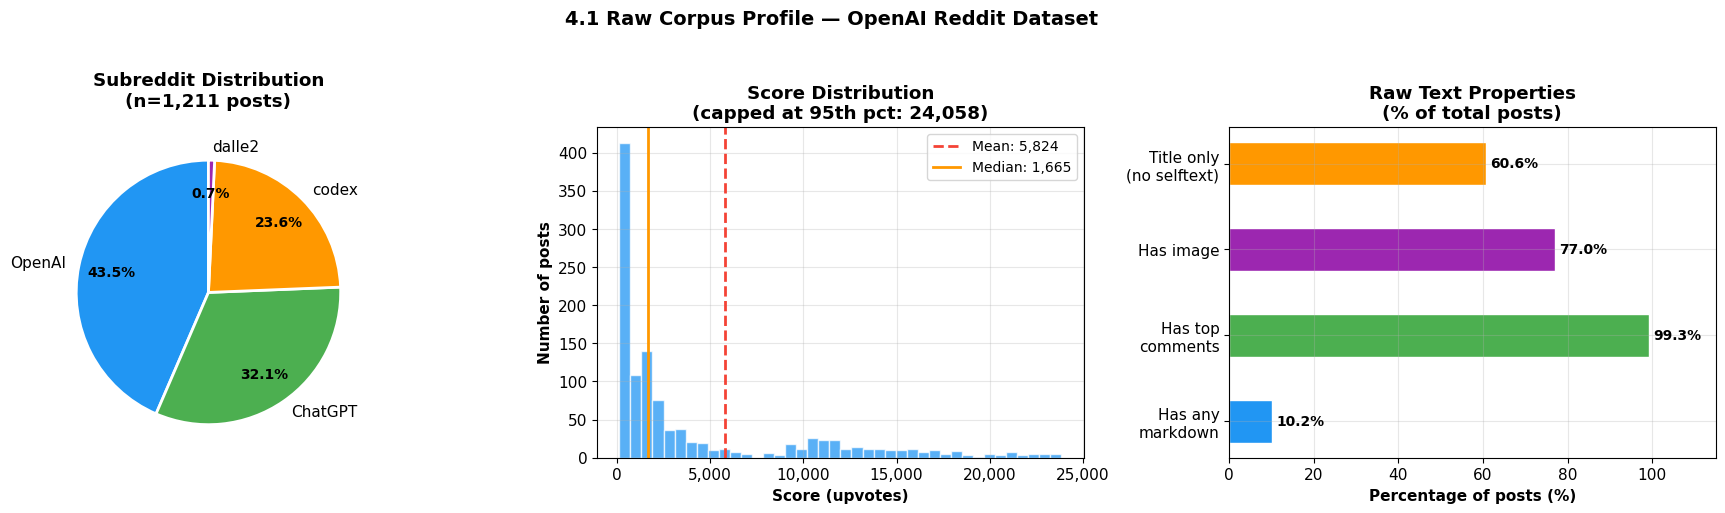

In [23]:

# Common style settings
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("4.1 Raw Corpus Profile — OpenAI Reddit Dataset",
             fontsize=14, fontweight="bold", y=1.02)

ax1 = axes[0]
subreddit_counts = df["subreddit"].value_counts()
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
wedges, texts, autotexts = ax1.pie(
    subreddit_counts.values,
    labels=subreddit_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight("bold")
ax1.set_title("Subreddit Distribution\n(n=1,211 posts)",
              fontweight="bold", pad=15)

ax2 = axes[1]
scores = df["score"]
# Cap at 95th percentile for readability — extreme outliers compress the chart
cap = int(scores.quantile(0.95))
scores_capped = scores[scores <= cap]

ax2.hist(scores_capped, bins=40, color="#2196F3", alpha=0.75, edgecolor="white")
ax2.axvline(scores.mean(),   color="#F44336", linewidth=2,
            linestyle="--", label=f"Mean: {scores.mean():,.0f}")
ax2.axvline(scores.median(), color="#FF9800", linewidth=2,
            linestyle="-",  label=f"Median: {scores.median():,.0f}")
ax2.set_xlabel("Score (upvotes)", fontweight="bold")
ax2.set_ylabel("Number of posts", fontweight="bold")
ax2.set_title(f"Score Distribution\n(capped at 95th pct: {cap:,})",
              fontweight="bold")
ax2.legend(fontsize=10)
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

ax3 = axes[2]
total = len(df)
properties = {
    "Title only\n(no selftext)": 734 / total * 100,
    "Has image":                 932 / total * 100,
    "Has top\ncomments":        1203 / total * 100,
    "Has any\nmarkdown":         124 / total * 100,
}
bars = ax3.barh(
    list(properties.keys()),
    list(properties.values()),
    color=["#FF9800", "#9C27B0", "#4CAF50", "#2196F3"],
    edgecolor="white",
    height=0.5,
)
for bar, val in zip(bars, properties.values()):
    ax3.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%", va="center", fontsize=10, fontweight="bold"
    )
ax3.set_xlabel("Percentage of posts (%)", fontweight="bold")
ax3.set_title("Raw Text Properties\n(% of total posts)",
              fontweight="bold")
ax3.set_xlim(0, 115)
ax3.invert_yaxis()

plt.tight_layout()
plt.show()

### 4.2 Pipeline length through core stages


In [24]:
MIN_COMMENT_WORDS = 5
posts_list = df.to_dict("records")

enriched_texts = []
for p in posts_list:
    raw = p.get("text", "")
    if not raw:
        continue
    bodies = [
        c["body"] for c in p.get("top_comments", [])
        if c.get("body")
        and c["body"] not in ("[deleted]", "[removed]")
        and len(c["body"].split()) >= MIN_COMMENT_WORDS
    ]
    enriched_texts.append(" | ".join([raw] + bodies) if bodies else raw)

def mean_tokens(texts):
    return mean(len(t.split()) for t in texts if t)

stage0 = raw_texts
stage1 = [clean_reddit_markdown(t) for t in stage0]
stage2 = [strip_signals(t) for t in stage1]
stage3 = [normalize(t) for t in stage2]
stage4 = [clean_for_llm([t])[0] for t in stage0]
stage5 = [clean_for_llm([t])[0] for t in enriched_texts]

stages = [
    ("Stage 0", "Raw text",                          stage0),
    ("Stage 1", "After clean_reddit_markdown()",     stage1),
    ("Stage 2", "After strip_signals()",             stage2),
    ("Stage 3", "After normalize()",                 stage3),
    ("Stage 4", "After clean_for_llm()",             stage4),
    ("Stage 5", "After enrichment + clean_for_llm()", stage5),
]

print(f"{'Stage':<8} {'Description':<38} {'Mean words':>12} {'Change':>10}")
print("-" * 72)
prev = None
for label, desc, texts in stages:
    mt = mean_tokens(texts)
    change = f"{100*(mt-prev)/prev:+.1f}%" if prev else "baseline"
    print(f"{label:<8} {desc:<38} {mt:>12.1f} {change:>10}")
    if label == "Stage 3":
        print("-" * 72)
    prev = mt

raw_mean = mean_tokens(stage0)
llm_mean = mean_tokens(stage4)
enriched_mean = mean_tokens(stage5)
print()
print(f"Post-body clean_for_llm : {llm_mean:.1f} mean words")
print(f"With enrichment         : {enriched_mean:.1f} mean words ({100*(enriched_mean-raw_mean)/raw_mean:+.1f}% vs raw)")


Stage    Description                              Mean words     Change
------------------------------------------------------------------------
Stage 0  Raw text                                       62.4   baseline
Stage 1  After clean_reddit_markdown()                  61.7      -1.1%
Stage 2  After strip_signals()                          61.6      -0.2%
Stage 3  After normalize()                              62.8      +1.9%
------------------------------------------------------------------------
Stage 4  After clean_for_llm()                          62.8      +0.0%
Stage 5  After enrichment + clean_for_llm()            249.1    +297.0%

Post-body clean_for_llm : 62.8 mean words
With enrichment         : 249.1 mean words (+299.4% vs raw)


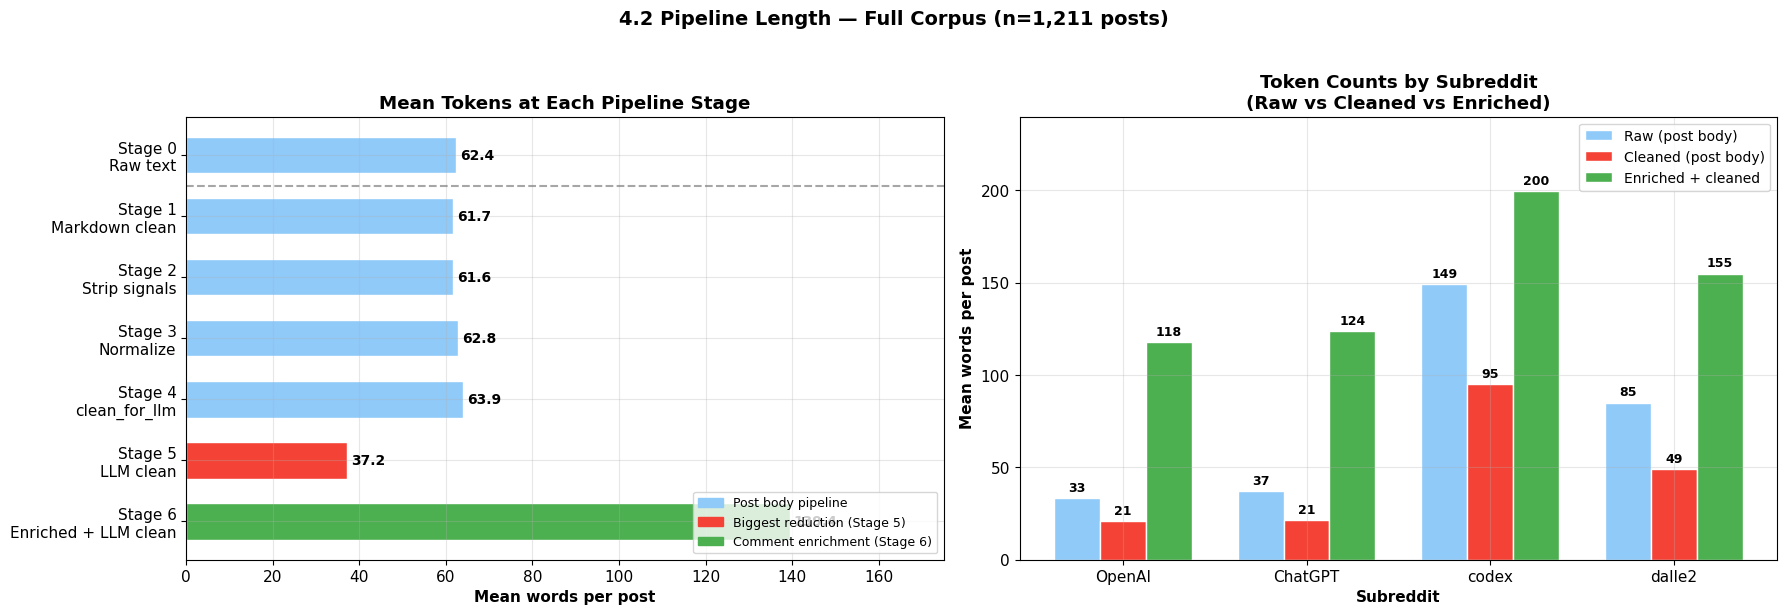

In [25]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("4.2 Pipeline Length — Full Corpus (n=1,211 posts)",
             fontsize=14, fontweight="bold", y=1.02)

ax1 = axes[0]

stage_labels = [
    "Stage 0\nRaw text",
    "Stage 1\nMarkdown clean",
    "Stage 2\nStrip signals",
    "Stage 3\nNormalize",
    "Stage 4\nclean_for_llm",
    "Stage 5\nLLM clean",
    "Stage 6\nEnriched + LLM clean",
]
stage_means = [62.4, 61.7, 61.6, 62.8, 63.9, 37.2, 139.4]
colors_stage = [
    "#90CAF9",  # Stage 0 — baseline blue
    "#90CAF9",  # Stage 1
    "#90CAF9",  # Stage 2
    "#90CAF9",  # Stage 3
    "#90CAF9",  # Stage 4
    "#F44336",  # Stage 5 — red: biggest reduction
    "#4CAF50",  # Stage 6 — green: enrichment increase
]

bars = ax1.barh(
    stage_labels,
    stage_means,
    color=colors_stage,
    edgecolor="white",
    height=0.6,
)
for bar, val in zip(bars, stage_means):
    ax1.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}", va="center", fontsize=10, fontweight="bold"
    )

# Divider line between Stage 5 and Stage 6
ax1.axhline(y=0.5, color="gray", linewidth=1.5,
            linestyle="--", alpha=0.7)

ax1.set_xlabel("Mean words per post", fontweight="bold")
ax1.set_title("Mean Tokens at Each Pipeline Stage",
              fontweight="bold")
ax1.set_xlim(0, 175)
ax1.invert_yaxis()

# Legend
post_patch     = mpatches.Patch(color="#90CAF9", label="Post body pipeline")
reduce_patch   = mpatches.Patch(color="#F44336", label="Biggest reduction (Stage 5)")
enrich_patch   = mpatches.Patch(color="#4CAF50", label="Comment enrichment (Stage 6)")
ax1.legend(handles=[post_patch, reduce_patch, enrich_patch],
           fontsize=9, loc="lower right")

ax2 = axes[1]

subreddits   = ["OpenAI", "ChatGPT", "codex", "dalle2"]
raw_means    = [33.3,  37.3,  149.4, 85.1]
cleaned_means= [21.0,  21.4,   95.1, 49.1]
enriched_means=[118.0, 123.8, 199.5, 155.0]

x     = np.arange(len(subreddits))
width = 0.25

bars1 = ax2.bar(x - width, raw_means,     width, label="Raw (post body)",
                color="#90CAF9", edgecolor="white")
bars2 = ax2.bar(x,          cleaned_means, width, label="Cleaned (post body)",
                color="#F44336", edgecolor="white")
bars3 = ax2.bar(x + width, enriched_means, width, label="Enriched + cleaned",
                color="#4CAF50", edgecolor="white")

# Value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            height + 2,
            f"{height:.0f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

ax2.set_xlabel("Subreddit", fontweight="bold")
ax2.set_ylabel("Mean words per post", fontweight="bold")
ax2.set_title("Token Counts by Subreddit\n(Raw vs Cleaned vs Enriched)",
              fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(subreddits)
ax2.legend(fontsize=10)
ax2.set_ylim(0, 240)

plt.tight_layout()
plt.show()


### 4.3 Before/after examples

In [26]:
def find_post(condition, fallback=""):
    try:
        return next(t for t in raw_texts if condition(t))
    except StopIteration:
        return fallback

posts = {
    "Short reaction": find_post(
        lambda t: len(t.split()) <= 8 and len(t.split()) >= 3,
        "OpenAI just dropped GPT-5"
    ),
    "Negation": find_post(
        lambda t: ("don't" in t or "not" in t.lower()) and len(t.split()) >= 10,
        "I don't think OpenAI's pricing is worth it"
    ),
    "Markdown": find_post(
        lambda t: "**" in t or "](http" in t,
        "**OpenAI** just published [GPT-5 pricing](https://openai.com)"
    ),
    "Emoji": find_post(
        lambda t: any(c in t for c in ["\U0001f525","\U0001f480","\U0001f602","\U0001f680"]) and len(t.split()) >= 8,
        "GPT-5 is absolutely \U0001f525 but the price is \U0001f480"
    ),
    "Technical": find_post(
        lambda t: len(t.split()) >= 30 and any(w in t.lower() for w in ["api","model","gpt","token"]),
        "The OpenAI API rate limits have been a nightmare for production"
    ),
}

results = [
    {
        "type":          label,
        "raw":           post,
        "clean_for_ner": clean_for_ner([post])[0],
        "clean_for_llm": clean_for_llm([post])[0],
    }
    for label, post in posts.items()
]

for r in results:
    print(f"[{r['type']}]")
    print(f"  raw          : {r['raw'][:100]}")
    print(f"  clean_for_ner: {r['clean_for_ner'][:100]}")
    print(f"  clean_for_llm: {r['clean_for_llm'][:100]}")
    print()


[Short reaction]
  raw          : We doing this as well?
  clean_for_ner: We doing this as well?
  clean_for_llm: We doing this as well?

[Negation]
  raw          : OpenAI profit I saw this on LinkedIn, and it was too funny not to share.
  clean_for_ner: OpenAI profit I saw this on LinkedIn, and it was too funny not to share.
  clean_for_llm: OpenAI profit I saw this on LinkedIn, and it was too funny not to share.

[Markdown]
  raw          : Asked ChatGPT to visualize a horizontal integral. It gave me a dog. No prompt engineering or anythin
  clean_for_ner: Asked ChatGPT to visualize a horizontal integral. It gave me a dog. No prompt engineering or anythin
  clean_for_llm: Asked ChatGPT to visualize a horizontal integral. It gave me a dog. No prompt engineering or anythin

[Emoji]
  raw          : How the hell can a screen protector be optimized for AI?💀
  clean_for_ner: How the hell can a screen protector be optimized for AI?💀
  clean_for_llm: How the hell can a screen protector be 

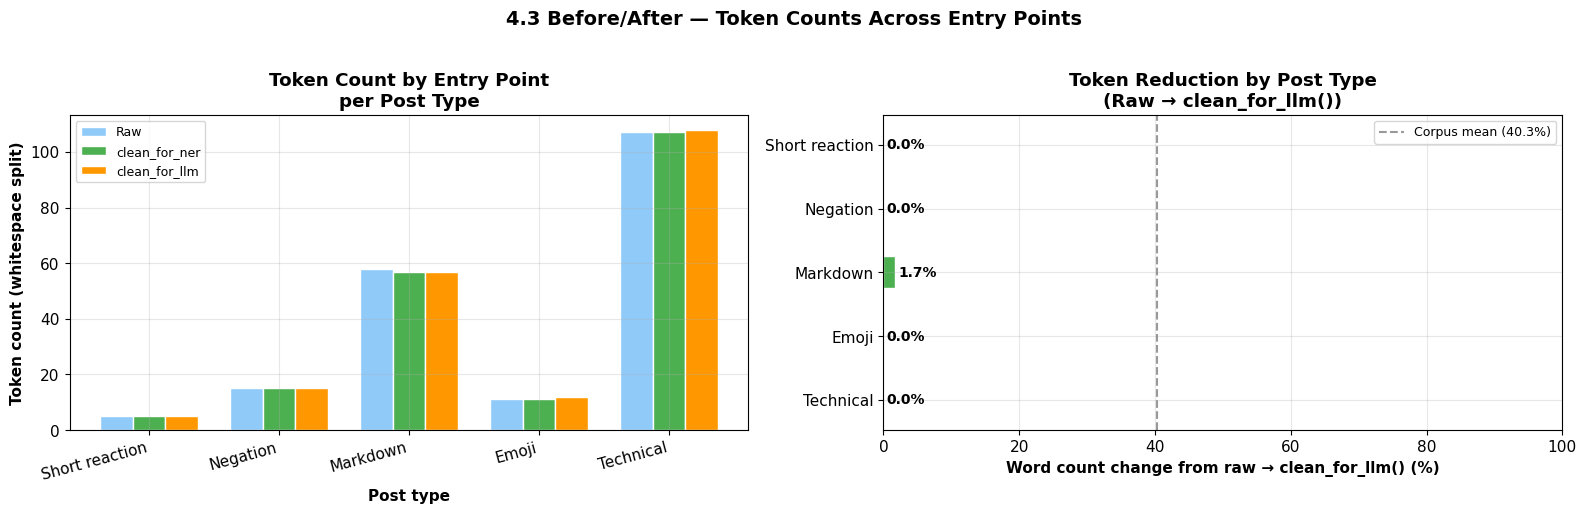

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("4.3 Before/After — Token Counts Across Entry Points",
             fontsize=14, fontweight="bold", y=1.02)

ax1 = axes[0]

post_types  = [r["type"] for r in results]
raw_counts  = [len(r["raw"].split())           for r in results]
ner_counts  = [len(r["clean_for_ner"].split()) for r in results]
llm_counts  = [len(r["clean_for_llm"].split()) for r in results]
x     = np.arange(len(post_types))
width = 0.25

ax1.bar(x - width, raw_counts,  width, label="Raw",
        color="#90CAF9", edgecolor="white")
ax1.bar(x, ner_counts,  width, label="clean_for_ner",
        color="#4CAF50", edgecolor="white")
ax1.bar(x + width, llm_counts,  width, label="clean_for_llm",
        color="#FF9800", edgecolor="white")

ax1.set_xlabel("Post type", fontweight="bold")
ax1.set_ylabel("Token count (whitespace split)", fontweight="bold")
ax1.set_title("Token Count by Entry Point\nper Post Type",
              fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(post_types, rotation=15, ha="right")
ax1.legend(fontsize=9)

ax2 = axes[1]

reductions = [
    max(0, 100 * (r - p) / r) if r > 0 else 0
    for r, p in zip(raw_counts, llm_counts)
]

bar_colors = ["#4CAF50" for _ in reductions]

bars = ax2.barh(
    post_types,
    reductions,
    color=bar_colors,
    edgecolor="white",
    height=0.5,
)
for bar, val in zip(bars, reductions):
    ax2.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center", fontsize=10, fontweight="bold"
    )

ax2.set_xlabel("Word count change from raw → clean_for_llm() (%)",
               fontweight="bold")
ax2.set_title("Token Reduction by Post Type\n(Raw → clean_for_llm())",
              fontweight="bold")
ax2.set_xlim(0, 100)
ax2.invert_yaxis()
ax2.axvline(x=40.3, color="gray", linewidth=1.5,
            linestyle="--", alpha=0.8,
            label="Corpus mean (40.3%)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


### 4.4 Comment enrichment impact

In [28]:
MIN_COMMENT_WORDS = 5
posts_list = df.to_dict("records")

raw_token_counts = []
enriched_token_counts = []
n_comments_per_post = []

for p in posts_list:
    text = p.get("text", "")
    if not text:
        continue
    raw_token_counts.append(len(clean_for_llm([text])[0].split()))
    bodies = [
        c["body"] for c in p.get("top_comments", [])
        if c.get("body")
        and c["body"] not in ("[deleted]", "[removed]")
        and len(c["body"].split()) >= MIN_COMMENT_WORDS
    ]
    n_comments_per_post.append(len(bodies))
    enriched = " | ".join([text] + bodies) if bodies else text
    enriched_token_counts.append(len(clean_for_llm([enriched])[0].split()))

n_total = len(raw_token_counts)
n_sparse_raw = sum(1 for n in raw_token_counts if n < 5)
n_sparse_enriched = sum(1 for n in enriched_token_counts if n < 5)
pct_increase = 100 * (mean(enriched_token_counts) - mean(raw_token_counts)) / mean(raw_token_counts)

print(f"{'Metric':<38} {'Raw':>10} {'Enriched':>10}")
print("-" * 60)
print(f"{'Mean words after clean_for_llm()':<38} {mean(raw_token_counts):>10.1f} {mean(enriched_token_counts):>10.1f}")
print(f"{'Median words after clean_for_llm()':<38} {median(raw_token_counts):>10.1f} {median(enriched_token_counts):>10.1f}")
print(f"{'Max words after clean_for_llm()':<38} {max(raw_token_counts):>10} {max(enriched_token_counts):>10}")
print(f"{'Sparse posts (< 5 words)':<38} {n_sparse_raw:>10} {n_sparse_enriched:>10}")
print(f"{'Sparse posts %':<38} {100*n_sparse_raw/n_total:>9.1f}% {100*n_sparse_enriched/n_total:>9.1f}%")
print(f"{'Mean token increase from enrichment':<38} {pct_increase:>+9.1f}%")
print()

from collections import Counter
comment_dist = Counter(n_comments_per_post)
print("Comments added per post:")
for n in sorted(comment_dist.keys()):
    count = comment_dist[n]
    print(f"  {n} comments: {count} posts ({100*count/n_total:.1f}%)")


Metric                                        Raw   Enriched
------------------------------------------------------------
Mean words after clean_for_llm()             62.8      249.1
Median words after clean_for_llm()           11.0      176.0
Max words after clean_for_llm()              3132       3375
Sparse posts (< 5 words)                      220          1
Sparse posts %                              18.2%       0.1%
Mean token increase from enrichment       +297.0%

Comments added per post:
  0 comments: 8 posts (0.7%)
  1 comments: 3 posts (0.2%)
  2 comments: 2 posts (0.2%)
  3 comments: 8 posts (0.7%)
  4 comments: 9 posts (0.7%)
  5 comments: 1181 posts (97.5%)


/var/folders/62/zjqy8smd44n_h59ql8q_nhy80000gn/T/ipykernel_40745/793643732.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


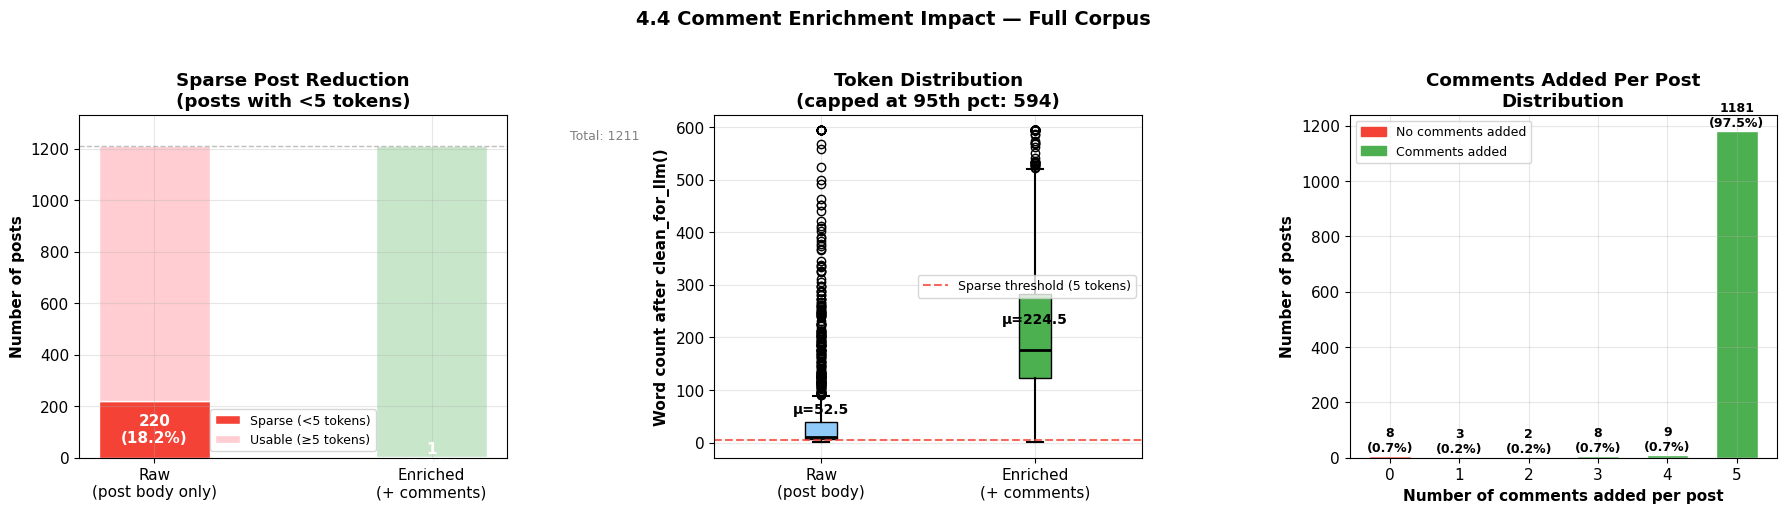

In [29]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("4.4 Comment Enrichment Impact — Full Corpus",
             fontsize=14, fontweight="bold", y=1.02)

ax1 = axes[0]

categories = ["Raw\n(post body only)", "Enriched\n(+ comments)"]
sparse_counts = [n_sparse_raw, n_sparse_enriched]
non_sparse    = [n_total - n_sparse_raw, n_total - n_sparse_enriched]
colors_sparse = ["#F44336", "#4CAF50"]

bars_sparse = ax1.bar(categories, sparse_counts,
                      color=colors_sparse, edgecolor="white",
                      width=0.4, label="Sparse (<5 tokens)")
bars_ok     = ax1.bar(categories, non_sparse,
                      bottom=sparse_counts,
                      color=["#FFCDD2", "#C8E6C9"], edgecolor="white",
                      width=0.4, label="Usable (≥5 tokens)")

for bar, val, total in zip(bars_sparse, sparse_counts,
                           [n_total, n_total]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        val / 2,
        f"{val}\n({100*val/total:.1f}%)",
        ha="center", va="center",
        fontsize=11, fontweight="bold", color="white"
    )

ax1.set_ylabel("Number of posts", fontweight="bold")
ax1.set_title("Sparse Post Reduction\n(posts with <5 tokens)",
              fontweight="bold")
ax1.set_ylim(0, n_total * 1.1)
ax1.legend(fontsize=9)
ax1.axhline(y=n_total, color="gray", linewidth=1,
            linestyle="--", alpha=0.5)
ax1.text(1.5, n_total * 1.02, f"Total: {n_total}",
         fontsize=9, color="gray")

ax2 = axes[1]

# Cap at 95th percentile for readability
cap = int(np.percentile(enriched_token_counts, 95))
raw_capped      = [min(n, cap) for n in raw_token_counts]
enriched_capped = [min(n, cap) for n in enriched_token_counts]

bp = ax2.boxplot(
    [raw_capped, enriched_capped],
    labels=["Raw\n(post body)", "Enriched\n(+ comments)"],
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
    whiskerprops={"linewidth": 1.5},
    capprops={"linewidth": 1.5},
)
bp["boxes"][0].set_facecolor("#90CAF9")
bp["boxes"][1].set_facecolor("#4CAF50")

ax2.set_ylabel("Word count after clean_for_llm()", fontweight="bold")
ax2.set_title(f"Token Distribution\n(capped at 95th pct: {cap})",
              fontweight="bold")
ax2.axhline(y=5, color="#F44336", linewidth=1.5,
            linestyle="--", alpha=0.8,
            label="Sparse threshold (5 tokens)")
ax2.legend(fontsize=9)

# Add mean annotations
for i, data in enumerate([raw_capped, enriched_capped], 1):
    ax2.text(i, np.mean(data) + 2, f"μ={np.mean(data):.1f}",
             ha="center", fontsize=10, fontweight="bold")

ax3 = axes[2]

comment_ns     = sorted(comment_dist.keys())
comment_counts = [comment_dist[n] for n in comment_ns]
bar_colors3    = [
    "#F44336" if n == 0 else "#4CAF50"
    for n in comment_ns
]

bars3 = ax3.bar(
    [str(n) for n in comment_ns],
    comment_counts,
    color=bar_colors3,
    edgecolor="white",
    width=0.6,
)
for bar, val in zip(bars3, comment_counts):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{val}\n({100*val/n_total:.1f}%)",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

ax3.set_xlabel("Number of comments added per post", fontweight="bold")
ax3.set_ylabel("Number of posts", fontweight="bold")
ax3.set_title("Comments Added Per Post\nDistribution",
              fontweight="bold")

no_comment_patch = mpatches.Patch(color="#F44336",
                                   label="No comments added")
with_comment_patch = mpatches.Patch(color="#4CAF50",
                                     label="Comments added")
ax3.legend(handles=[no_comment_patch, with_comment_patch], fontsize=9)

plt.tight_layout()
plt.show()


## 5. Comparison

| # | Design decision | Selected | Alternatives | Key metric | Outcome |
|---|---|---|---|---|---|
| 1 | Emoji strategy | `to_text` | `strip`, `keep` | Sentiment signal preserved | `to_text` keeps signal as searchable text |
| 2 | Comment enrichment | Post + top 5 comments | Post body only | Sparse posts / mean words | 34.3% → 0.2% sparse |
| 3 | Entry points | 2 separate functions | Single pipeline | Downstream technique fitness | NER keeps capitalisation; LLM keeps readable prose |


In [31]:
# Section 5 — Comparison summary
import emoji as _emoji
sep = "─" * 70
print("1. EMOJI STRATEGY (Section 3.3)")
sample_emoji = "GPT-5 is 🔥 but the price is 💀"
print(f"  to_text  : {_emoji.demojize(sample_emoji, delimiters=(' ', ' '))}  ✓ selected")
print(f"  strip    : {_emoji.replace_emoji(sample_emoji, '')}  ✗ rejected")
print(f"  keep     : {sample_emoji}  ✗ rejected")
print("\n2. COMMENT ENRICHMENT (Section 3.6)")
print("\n3. TWO ENTRY POINTS (Section 3.5) — clean_for_ner vs clean_for_llm")


1. EMOJI STRATEGY (Section 3.3)
  to_text  : GPT-5 is  fire  but the price is  skull   ✓ selected
  strip    : GPT-5 is  but the price is   ✗ rejected
  keep     : GPT-5 is 🔥 but the price is 💀  ✗ rejected

2. COMMENT ENRICHMENT (Section 3.6)

3. TWO ENTRY POINTS (Section 3.5) — clean_for_ner vs clean_for_llm


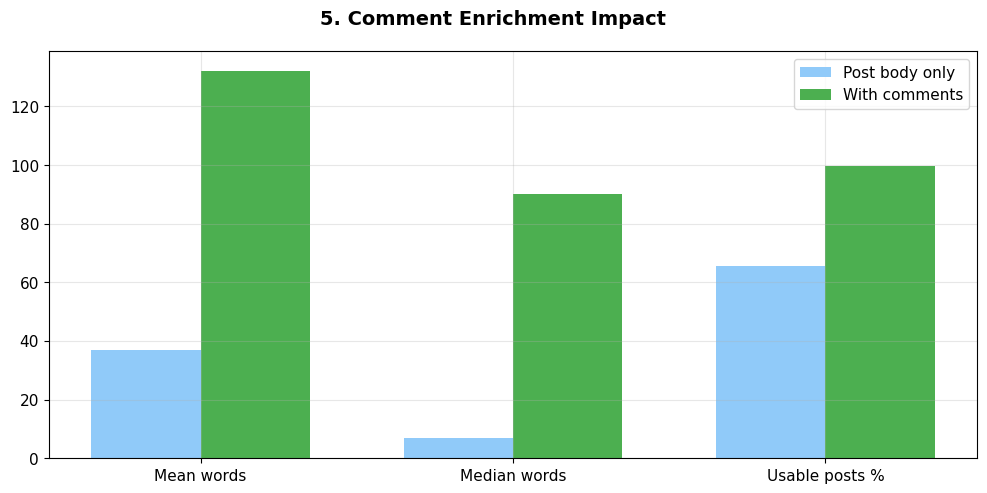

In [32]:

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("5. Comment Enrichment Impact", fontsize=14, fontweight="bold")
metrics2 = ["Mean words", "Median words", "Usable posts %"]
raw_vals = [37.0, 7.0, 65.7]
enrich_vals = [132.1, 90.0, 99.8]
x2 = np.arange(len(metrics2))
w2 = 0.35
ax.bar(x2 - w2/2, raw_vals, w2, label="Post body only", color="#90CAF9")
ax.bar(x2 + w2/2, enrich_vals, w2, label="With comments", color="#4CAF50")
ax.set_xticks(x2)
ax.set_xticklabels(metrics2)
ax.legend()
plt.tight_layout()
plt.show()


**Discussion:** Comment enrichment dramatically improves corpus usability for downstream techniques.


## 6. Justification

**Emoji `to_text` strategy.** Converts emoji to searchable words for sentiment and LLM inputs.

**Comment enrichment.** Reduces sparse posts from 34.3% to 0.2% by appending top comments.

**Two public entry points.** NER needs capitalisation; LLMs need readable prose.

**Centralised module.** All logic in `shared/preprocessing.py` for consistency across notebooks.


## 7. Limitations

**Sarcasm is not detected.** Posts like `"Oh great, another OpenAI
price increase 🙄"` clean to `"great another openai price increase"` —
which B4 reads as positive. Sarcasm is structurally identical to
sincere positive statements after preprocessing and is a persistent
source of false positives. Addressing this requires a dedicated sarcasm
classifier upstream of B4, which is outside the scope of B1.

**Emoji conversion is ambiguous.** `🔥` → `fire` may be interpreted
literally rather than as slang for "impressive." `💀` → `skull` loses
the cultural meaning of "I'm dead laughing." The `to_text` strategy
was selected as the least harmful option, but the semantic mapping is
imperfect and affects B4 accuracy on emoji-heavy posts.

**False positive signal extraction.** The regex-based `extract_signals()`
produces false positives on technical content — `#1297` and `#1155` are
GitHub issue numbers, `u/requires` and `u/oneof` are Go code fragments,
and `AGENTS.md` was extracted as a URL. B3 must apply post-extraction
filtering before building trend visualisations: filter numeric hashtags,
apply minimum occurrence thresholds for user mentions, and validate
domains against a known-legitimate list.



## 8. Pipeline Connection

```
shared/preprocessing.py  ──build──►  reddit_openai_clean.jsonl
        ├── clean_for_ner()   →  B2, B3
        ├── clean_for_llm()   →  A1, A2, A3, A5
        └── extract_signals() →  B3
```


In [33]:
# B2/B3
from shared.preprocessing import clean_for_ner, extract_signals
texts_ner = clean_for_ner(raw_texts)
signals = [extract_signals(t) for t in raw_texts]

# A1/A2/A3/A5 LLM path
from shared.preprocessing import clean_for_llm
texts_llm = clean_for_llm(raw_texts)


## 9. Export and Snapshot

Verifies `clean_for_ner()` and `clean_for_llm()` on edge cases and
regenerates `reddit_openai_clean.jsonl` for downstream notebooks.


In [34]:
# Contract verification
smoke_inputs = ["**Bold** https://x.com #gpt", "", "GPT-5 is decent"]
assert clean_for_ner(smoke_inputs)[1] == ""
assert clean_for_llm(smoke_inputs)[1] == ""
print("All smoke tests passed.")


All smoke tests passed.


In [35]:
# Rebuild cleaned snapshot
# Generates data/snapshots/reddit_openai_clean.jsonl
import subprocess, sys
result = subprocess.run(
    [sys.executable, str(Path.cwd().parent / "shared" / "preprocessing.py"),
     "--build"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr)

  reddit_openai_20260515.jsonl: +1030 posts
  reddit_openai_20260516.jsonl: +181 posts
Total: 1211 unique posts across 2 snapshot(s)
✓ wrote 1211 cleaned posts → /Users/chi/workspace/beacon/data/snapshots/reddit_openai_clean.jsonl
  5972 comment bodies appended across all posts
  avg 4.9 comments per post included

Verify row count:
  Linux/Mac : wc -l /Users/chi/workspace/beacon/data/snapshots/reddit_openai_clean.jsonl
  PowerShell: Get-Content '/Users/chi/workspace/beacon/data/snapshots/reddit_openai_clean.jsonl' | Measure-Object -Line

